In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amazonml2025-absolut/sample_test.csv
/kaggle/input/amazonml2025-absolut/sample_test_out.csv
/kaggle/input/amazonml2025-absolut/train.csv
/kaggle/input/amazonml2025-absolut/test.csv


In [2]:
def smape_loss(y_pred, y_true, epsilon=1e-8):
    numerator = torch.abs(y_pred - y_true)
    denominator = (torch.abs(y_true) + torch.abs(y_pred)).clamp(min=epsilon) / 2
    return torch.mean(numerator / denominator)

In [ ]:
quantities = {
    'oz': 'oz',
    'ounce': 'oz',
    
}

In [1]:
import pandas as pd

In [2]:
traind = pd.read_csv('/kaggle/input/amazonml2025-absolut/train.csv')
traind.head()

,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


## Pre Processing ##

In [3]:
import pandas as pd
import re

def extract_value_unit_packs(text):
    # Extract value
    value_match = re.search(r'Value:\s*([\d.]+)', text)
    value = float(value_match.group(1)) if value_match else None

    # Extract unit
    unit_match = re.search(r'Unit:\s*(\w+)', text)
    unit = unit_match.group(1) if unit_match else None

    # Extract number of packs
    pack_match = re.search(r'Pack of\s*(\d+)', text, re.IGNORECASE)
    num_of_packs = int(pack_match.group(1)) if pack_match else 1

    return pd.Series([value, unit, num_of_packs])
traind[['value_extracted', 'unit_extracted', 'num_of_packs']] = traind['catalog_content'].apply(extract_value_unit_packs)


In [7]:
traind.head()

,sample_id,catalog_content,image_link,price,value_extracted,unit_extracted,num_of_packs
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,72.00,Fl,6.0
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,32.00,Ounce,4.0
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,11.40,Ounce,6.0
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,11.25,Ounce,1.0
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,12.00,Count,1.0


In [8]:
traind.isna().sum()

sample_id            0
catalog_content      0
image_link           0
price                0
value_extracted    940
unit_extracted       3
num_of_packs         0
dtype: int64

In [4]:
# Convert 'catalog_content' to lowercase
traind['catalog_content'] = traind['catalog_content'].str.lower()

# Convert 'unit_extracted' to lowercase (only if it's a string)
traind['unit_extracted'] = traind['unit_extracted'].apply(lambda x: x.lower() if isinstance(x, str) else x)


In [14]:
traind['unit_extracted'].isna().sum()

3

In [11]:
import numpy as np

# Count actual NaN values
traind['unit_extracted'].isna().sum()


3

In [11]:
traind.to_csv("prep_data-2.csv")

In [19]:
# Filtered copy
traind_filtered = traind[
    (traind['value_extracted'].notnull()) &
    (traind['value_extracted'] != 0) &
    (traind['unit_extracted'].notnull())
].copy()
traind_filtered.shape

(74018, 7)

In [20]:
traind_filtered['unit_extracted'].isna().sum()

0

In [21]:
traind_filtered['unit_extracted'].unique()

array(['fl', 'ounce', 'count', 'fluid', 'oz', 'ounces', 'pound', 'gram',
       'grams', 'lb', 'each', 'liters', 'gramm', 'ct', 'millilitre',
       'jar', 'bottle', 'can', 'tea', '20', '24', 'pack', 'piece', 'gr',
       'milliliter', 'mililitro', '2', 'pounds', 'kg', 'bag', 'in', 'k',
       'sq', 'ml', 'packs', 'box', '8', 'pouch', 'bucket', 'per', '1',
       'comes', 'units', 'case', 'product_weight', 'foot', 'cm', 'unità',
       'paper', 'capsule', 'bottles', 'ziplock', 'ltr', 'carton', '7'],
      dtype=object)

In [8]:
traind_filtered.drop('sample_id', axis= 1)
traind_filtered.head()

,sample_id,catalog_content,image_link,price,value_extracted,unit_extracted,num_of_packs
0,33127,"item name: la victoria green taco sauce mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,72.00,fl,6.0
1,198967,"item name: salerno cookies, the original butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,32.00,ounce,4.0
2,261251,"item name: bear creek hearty soup bowl, creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,11.40,ounce,6.0
3,55858,item name: judee’s blue cheese powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,11.25,ounce,1.0
4,292686,"item name: kedem sherry cooking wine, 12.7 oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,12.00,count,1.0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


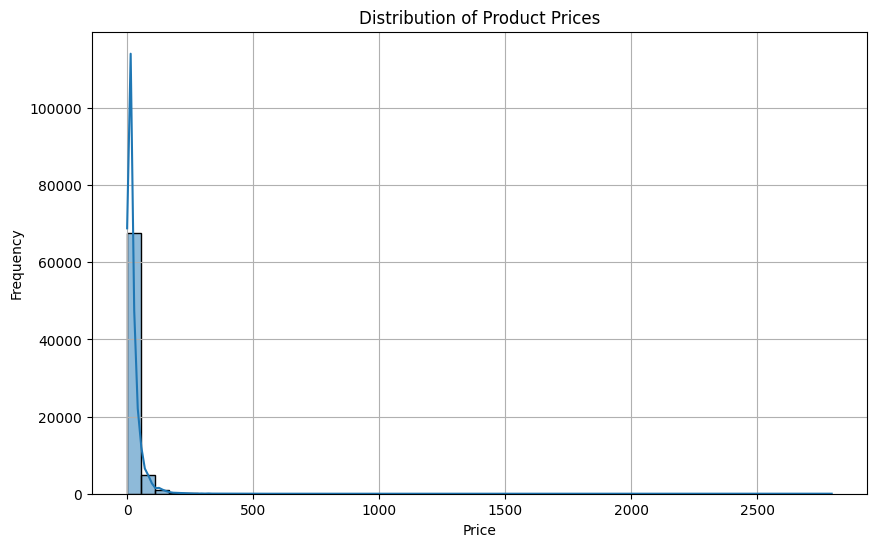

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(traind_filtered['price'], bins=50, kde=True)
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


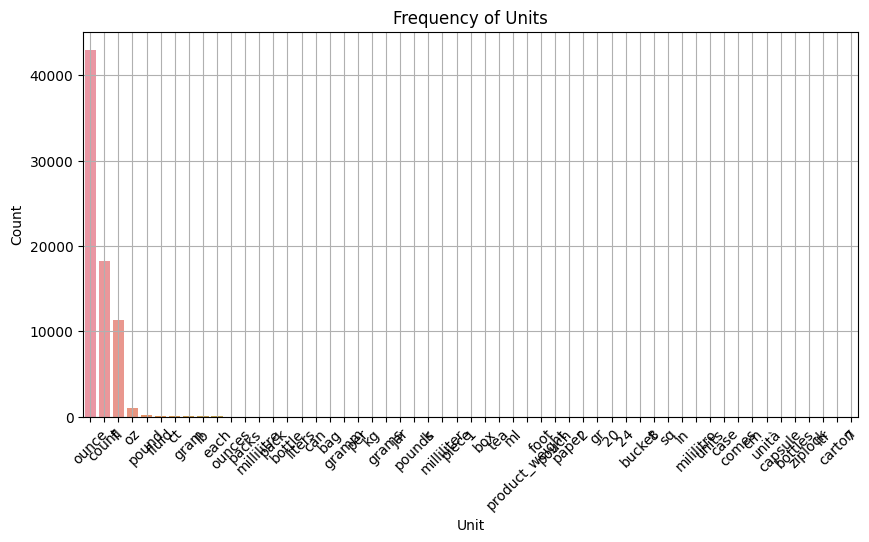

In [18]:
plt.figure(figsize=(10, 5))
sns.countplot(data=traind_filtered, x='unit_extracted', order=traind_filtered['unit_extracted'].value_counts().index)
plt.title('Frequency of Units')
plt.xlabel('Unit')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


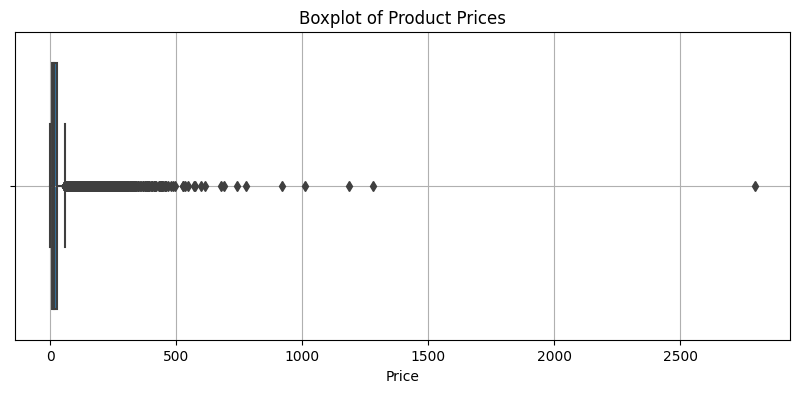

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.boxplot(x=traind_filtered['price'])
plt.title('Boxplot of Product Prices')
plt.xlabel('Price')
plt.grid(True)
plt.show()


In [28]:
(traind_filtered['price'] <= 10).sum()

28390

In [4]:
traind_filtered.columns

NameError: name 'traind_filtered' is not defined

In [15]:
traind_filtered_small = traind_filtered.iloc[:1000:, ::]

In [16]:
traind_filtered_small.shape

(1000, 7)

In [ ]:
# 📦 Imports
import pandas as pd
import numpy as np
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
from io import BytesIO
import requests
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import re

# 📁 Dataset
df = traind_filtered.copy()
df['catalog_content'] = df['catalog_content'].str.lower()

# 🔢 Tabular Features
unit_encoder = OneHotEncoder(handle_unknown='ignore')
unit_encoded = unit_encoder.fit_transform(df[['unit_extracted']].fillna('unknown')).toarray()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['value_extracted', 'num_of_packs']].fillna(0))

tabular_data = np.hstack([scaled_features, unit_encoded])

# 📝 Text Features
tfidf = TfidfVectorizer(max_features=100)
text_data = tfidf.fit_transform(df['catalog_content'].fillna("")).toarray()

# 🎯 Targets
targets = df['price'].values

# 🖼️ Image Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

# 🌐 Fetch Image from URL
def fetch_image_from_url(url):
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        return img
    except:
        return Image.new('RGB', (224, 224), color=(255, 255, 255))  # fallback blank image

# 🧮 Dataset Class
class PriceDataset(Dataset):
    def __init__(self, df, transform, tabular_data, text_data, targets=None):
        self.df = df
        self.transform = transform
        self.tabular_data = tabular_data
        self.text_data = text_data
        self.targets = targets

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = fetch_image_from_url(row['image_link'])
        image = self.transform(image)

        tabular = torch.tensor(self.tabular_data[idx], dtype=torch.float32)
        text = torch.tensor(self.text_data[idx], dtype=torch.float32)

        if self.targets is not None:
            target = torch.tensor(self.targets[idx], dtype=torch.float32)
            return image, tabular, text, target
        else:
            return image, tabular, text

# 🧠 Model Architecture
class PricePredictor(nn.Module):
    def __init__(self, tabular_dim, text_dim):
        super().__init__()
        self.cnn = models.efficientnet_b0(pretrained=True)
        self.cnn.classifier = nn.Identity()

        # Freeze early layers (features.0 to features.5)
        for name, param in self.cnn.named_parameters():
            if any(f"features.{i}" in name for i in range(7)):
                param.requires_grad = False

        self.tabular_fc = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.text_fc = nn.Sequential(
            nn.Linear(text_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.final_fc = nn.Sequential(
            nn.Linear(1280 + 64 + 64, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular, text):
        img_feat = self.cnn(image)
        tab_feat = self.tabular_fc(tabular)
        text_feat = self.text_fc(text)
        combined = torch.cat([img_feat, tab_feat, text_feat], dim=1)
        return self.final_fc(combined).squeeze()

# 📐 SMAPE Loss Function
def smape_loss(y_pred, y_true, epsilon=1e-8):
    numerator = torch.abs(y_pred - y_true)
    denominator = (torch.abs(y_true) + torch.abs(y_pred)).clamp(min=epsilon) / 2
    return torch.mean(numerator / denominator)

# 🏋️ Training Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PricePredictor(tabular_dim=tabular_data.shape[1], text_dim=text_data.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 📊 Parameter Summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model initialized on {device}")
print(f"📊 Total parameters: {total_params:,}")
print(f"🛠️ Trainable parameters: {trainable_params:,}")

# 📦 DataLoader
train_dataset = PriceDataset(df, transform, tabular_data, text_data, targets)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 🔁 Training Loop with Progress Bar
for epoch in range(2):
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=True)

    for image, tabular, text, target in loop:
        image, tabular, text, target = image.to(device), tabular.to(device), text.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(image, tabular, text)
        loss = smape_loss(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        loop.set_postfix(smape=loss.item())

    print(f"Epoch {epoch+1} completed. Avg SMAPE: {total_loss / len(train_loader):.4f}")
    

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Model initialized on cuda
📊 Total parameters: 4,198,205
🛠️ Trainable parameters: 1,320,049


Epoch 1:  94%|█████████▍| 2183/2314 [3:01:24<12:40,  5.81s/it, smape=0.498]  

In [1]:
print('jaisriram')

jaisriram


In [21]:
print("Using device:", device)

Using device: cuda


In [23]:
# 📁 Load Test Data
test_df = pd.read_csv('/kaggle/input/amazonml2025-absolut/test.csv')
test_df = test_df.iloc[:1000:,::]
test_df['catalog_content'] = test_df['catalog_content'].str.lower()

# 🧪 Extract tabular features from catalog_content
def extract_value_unit_packs(text):
    value_match = re.search(r'Value:\s*([\d.]+)', text)
    value = float(value_match.group(1)) if value_match else 0.0

    unit_match = re.search(r'Unit:\s*(\w+)', text)
    unit = unit_match.group(1).lower() if unit_match else 'unknown'

    pack_match = re.search(r'Pack of\s*(\d+)', text, re.IGNORECASE)
    num_of_packs = int(pack_match.group(1)) if pack_match else 1

    return pd.Series([value, unit, num_of_packs])

test_df[['value_extracted', 'unit_extracted', 'num_of_packs']] = test_df['catalog_content'].apply(extract_value_unit_packs)

# 🔢 Tabular Features
unit_encoded_test = unit_encoder.transform(test_df[['unit_extracted']]).toarray()
scaled_features_test = scaler.transform(test_df[['value_extracted', 'num_of_packs']])
tabular_test = np.hstack([scaled_features_test, unit_encoded_test])

# 📝 Text Features
text_test = tfidf.transform(test_df['catalog_content'].fillna("")).toarray()

# 🧮 Test Dataset Class
class TestDataset(Dataset):
    def __init__(self, df, transform, tabular_data, text_data):
        self.df = df
        self.transform = transform
        self.tabular_data = tabular_data
        self.text_data = text_data

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = fetch_image_from_url(row['image_link'])
        image = self.transform(image)

        tabular = torch.tensor(self.tabular_data[idx], dtype=torch.float32)
        text = torch.tensor(self.text_data[idx], dtype=torch.float32)

        return image, tabular, text

# 📦 DataLoader
test_dataset = TestDataset(test_df, transform, tabular_test, text_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

from tqdm import tqdm  # Add this import

model.eval()
predictions = []

with torch.no_grad():
    for image, tabular, text in tqdm(test_loader, desc="Predicting"):
        image, tabular, text = image.to(device), tabular.to(device), text.to(device)
        output = model(image, tabular, text)
        predictions.extend(output.cpu().numpy())


# 📤 Submission
submission = pd.DataFrame({
    'sample_id': test_df['sample_id'],
    'price': predictions
})
submission.to_csv('submission-3.csv', index=False)
print('the predictions are saved to submission file')

Predicting: 100%|██████████| 32/32 [03:00<00:00,  5.66s/it]


In [34]:
submission.head()

,sample_id,price
0,100179,13.717413
1,245611,6.616852
2,146263,9.520986
3,95658,6.414309
4,36806,14.004135


In [9]:
# =========================================================
# 📦 Imports
# =========================================================
import pandas as pd
import numpy as np
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
from io import BytesIO
import requests
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

torch.backends.cudnn.benchmark = True  # optimize CNN on GPU

# =========================================================
# 📁 Dataset Preprocessing
# =========================================================
df = traind_filtered.copy()  # your filtered training dataframe
# df = df.iloc[:100:, ::]
df['catalog_content'] = df['catalog_content'].str.lower()

# --- Tabular Features ---
unit_encoder = OneHotEncoder(handle_unknown='ignore')
unit_encoded = unit_encoder.fit_transform(df[['unit_extracted']].fillna('unknown')).toarray()

tabular_scaler = StandardScaler()
scaled_features = tabular_scaler.fit_transform(df[['value_extracted', 'num_of_packs']].fillna(0))
tabular_data = np.hstack([scaled_features, unit_encoded])

# --- Text Features ---
tfidf = TfidfVectorizer(max_features=100)
text_data = tfidf.fit_transform(df['catalog_content'].fillna("")).toarray()

# --- Targets ---
targets = df['price'].values

# =========================================================
# 🖼️ Image Preprocessing
# =========================================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def fetch_image_from_url(url):
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        return img
    except:
        return Image.new('RGB', (224, 224), color=(255, 255, 255))

# =========================================================
# 🧮 Dataset Class
# =========================================================
class PriceDataset(Dataset):
    def __init__(self, df, tabular_data, text_data, targets=None, transform=None):
        self.df = df
        self.tabular_data = tabular_data
        self.text_data = text_data
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = fetch_image_from_url(row['image_link'])
        if self.transform:
            image = self.transform(image)

        tabular = torch.tensor(self.tabular_data[idx], dtype=torch.float32)
        text = torch.tensor(self.text_data[idx], dtype=torch.float32)

        if self.targets is not None:
            target = torch.tensor(self.targets[idx], dtype=torch.float32)
            return image, tabular, text, target
        else:
            return image, tabular, text

# =========================================================
# 🧠 Model Architecture
# =========================================================
class PricePredictor(nn.Module):
    def __init__(self, tabular_dim, text_dim):
        super().__init__()
        self.cnn = models.efficientnet_b0(pretrained=True)
        self.cnn.classifier = nn.Identity()

        # Freeze early CNN layers
        for name, param in self.cnn.named_parameters():
            if any(f"features.{i}" in name for i in range(7)):
                param.requires_grad = False

        self.tabular_fc = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.text_fc = nn.Sequential(
            nn.Linear(text_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.final_fc = nn.Sequential(
            nn.Linear(1280 + 64 + 64, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular, text):
        img_feat = self.cnn(image)
        tab_feat = self.tabular_fc(tabular)
        text_feat = self.text_fc(text)
        combined = torch.cat([img_feat, tab_feat, text_feat], dim=1)
        return self.final_fc(combined).squeeze()

# =========================================================
# 📐 SMAPE Loss Function
# =========================================================
def smape_loss(y_pred, y_true, epsilon=1e-8):
    numerator = torch.abs(y_pred - y_true)
    denominator = (torch.abs(y_true) + torch.abs(y_pred)).clamp(min=epsilon) / 2
    return torch.mean(numerator / denominator)

# =========================================================
# 🏋️ Training Setup
# =========================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Training on: {device}")

model = PricePredictor(tabular_dim=tabular_data.shape[1], text_dim=text_data.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
amp_scaler = torch.cuda.amp.GradScaler()  # for mixed precision

# =========================================================
# 📦 DataLoader
# =========================================================
train_dataset = PriceDataset(df, tabular_data, text_data, targets, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)

# =========================================================
# 🔁 Training Loop
# =========================================================
for epoch in range(1):  # increase epochs as needed
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=True)

    for image, tabular, text, target in loop:
        image = image.to(device, non_blocking=True)
        tabular = tabular.to(device, non_blocking=True)
        text = text.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            output = model(image, tabular, text)
            loss = smape_loss(output, target)

        amp_scaler.scale(loss).backward()
        amp_scaler.step(optimizer)
        amp_scaler.update()

        total_loss += loss.item()
        loop.set_postfix(SMAPE=loss.item())

    print(f"✅ Epoch {epoch+1} completed | Avg SMAPE: {total_loss / len(train_loader):.4f}")

print("🎉 Training complete!")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


✅ Training on: cuda


100%|██████████| 20.5M/20.5M [00:00<00:00, 135MB/s] 
/tmp/ipykernel_37/1947307836.py:144: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler()  # for mixed precision
Epoch 1:   0%|          | 0/2314 [00:00<?, ?it/s]/tmp/ipykernel_37/1947307836.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1: 100%|██████████| 2314/2314 [3:39:08<00:00,  5.68s/it, SMAPE=0.701]  

✅ Epoch 1 completed | Avg SMAPE: 0.6834
🎉 Training complete!


In [10]:
# ✅ Save only model weights
torch.save(model.state_dict(), "price_predictor_weights-3.pth")

In [11]:
# =========================================================
# 📁 Load Test Data
# =========================================================
test_df = pd.read_csv('/kaggle/input/amazonml2025-absolut/test.csv')
# test_df = test_df.iloc[:100, :]  # for demo/testing
test_df['catalog_content'] = test_df['catalog_content'].str.lower()

# =========================================================
# 🧪 Extract tabular features
# =========================================================
def extract_value_unit_packs(text):
    value_match = re.search(r'Value:\s*([\d.]+)', text)
    value = float(value_match.group(1)) if value_match else 0.0

    unit_match = re.search(r'Unit:\s*(\w+)', text)
    unit = unit_match.group(1).lower() if unit_match else 'unknown'

    pack_match = re.search(r'Pack of\s*(\d+)', text, re.IGNORECASE)
    num_of_packs = int(pack_match.group(1)) if pack_match else 1

    return pd.Series([value, unit, num_of_packs])

test_df[['value_extracted', 'unit_extracted', 'num_of_packs']] = test_df['catalog_content'].apply(extract_value_unit_packs)

# =========================================================
# 🔢 Tabular Features
# =========================================================
unit_encoded_test = unit_encoder.transform(test_df[['unit_extracted']]).toarray()
scaled_features_test = tabular_scaler.transform(test_df[['value_extracted', 'num_of_packs']])
tabular_test = np.hstack([scaled_features_test, unit_encoded_test])

# =========================================================
# 📝 Text Features
# =========================================================
text_test = tfidf.transform(test_df['catalog_content'].fillna("")).toarray()

# =========================================================
# 🧮 Test Dataset Class
# =========================================================
class TestDataset(Dataset):
    def __init__(self, df, transform, tabular_data, text_data):
        self.df = df
        self.transform = transform
        self.tabular_data = tabular_data
        self.text_data = text_data

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = fetch_image_from_url(row['image_link'])
        image = self.transform(image)

        tabular = torch.tensor(self.tabular_data[idx], dtype=torch.float32)
        text = torch.tensor(self.text_data[idx], dtype=torch.float32)

        return image, tabular, text

# =========================================================
# 📦 DataLoader
# =========================================================
test_dataset = TestDataset(test_df, transform, tabular_test, text_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

# =========================================================
# 🔮 Predictions
# =========================================================
model.eval()
predictions = []

with torch.no_grad():
    for image, tabular, text in tqdm(test_loader, desc="Predicting"):
        image = image.to(device, non_blocking=True)
        tabular = tabular.to(device, non_blocking=True)
        text = text.to(device, non_blocking=True)

        with torch.cuda.amp.autocast():  # optional
            output = model(image, tabular, text)

        predictions.extend(output.cpu().numpy())

# =========================================================
# 📤 Submission
# =========================================================
submission = pd.DataFrame({
    'sample_id': test_df['sample_id'],
    'price': predictions
})
submission.to_csv('submission-3.csv', index=False)
print("✅ Submission saved as 'submission-3.csv'")


Predicting:   0%|          | 0/2344 [00:00<?, ?it/s]/tmp/ipykernel_37/3359640951.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # optional
Predicting: 100%|██████████| 2344/2344 [3:43:27<00:00,  5.72s/it]  

✅ Submission saved as 'submission-3.csv'


In [1]:
print(model)

NameError: name 'model' is not defined

# On a verge to increase Performance

## Using B3 Model

In [9]:
# =========================================================
# 📦 Imports
# =========================================================
import pandas as pd
import numpy as np
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
from io import BytesIO
import requests
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

torch.backends.cudnn.benchmark = True  # optimize CNN on GPU

# =========================================================
# 📁 Dataset Preprocessing
# =========================================================
df = traind_filtered.copy()  # your filtered training dataframe
# df = df.iloc[:1000:, ::]
df['catalog_content'] = df['catalog_content'].str.lower()

# --- Tabular Features ---
unit_encoder = OneHotEncoder(handle_unknown='ignore')
unit_encoded = unit_encoder.fit_transform(df[['unit_extracted']].fillna('unknown')).toarray()

tabular_scaler = StandardScaler()
scaled_features = tabular_scaler.fit_transform(df[['value_extracted', 'num_of_packs']].fillna(0))
tabular_data = np.hstack([scaled_features, unit_encoded])

# --- Text Features ---
tfidf = TfidfVectorizer(max_features=100)
text_data = tfidf.fit_transform(df['catalog_content'].fillna("")).toarray()

# --- Targets ---
targets = df['price'].values

# =========================================================
# 🖼️ Image Preprocessing
# =========================================================
transform = transforms.Compose([
    transforms.Resize((300, 300)),  # Required for EfficientNet-B3
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def fetch_image_from_url(url):
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        return img
    except:
        return Image.new('RGB', (224, 224), color=(255, 255, 255))

# =========================================================
# 🧮 Dataset Class
# =========================================================
class PriceDataset(Dataset):
    def __init__(self, df, tabular_data, text_data, targets=None, transform=None):
        self.df = df
        self.tabular_data = tabular_data
        self.text_data = text_data
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = fetch_image_from_url(row['image_link'])
        if self.transform:
            image = self.transform(image)

        tabular = torch.tensor(self.tabular_data[idx], dtype=torch.float32)
        text = torch.tensor(self.text_data[idx], dtype=torch.float32)

        if self.targets is not None:
            target = torch.tensor(self.targets[idx], dtype=torch.float32)
            return image, tabular, text, target
        else:
            return image, tabular, text

# =========================================================
# 🧠 Model Architecture
# =========================================================
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

class PricePredictor(nn.Module):
    def __init__(self, tabular_dim, text_dim):
        super().__init__()
        self.cnn = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
        self.cnn.classifier = nn.Identity()

        # Freeze early CNN layers
        for name, param in self.cnn.named_parameters():
            if any(f"features.{i}" in name for i in range(7)):
                param.requires_grad = False

        self.tabular_fc = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.text_fc = nn.Sequential(
            nn.Linear(text_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.final_fc = nn.Sequential(
            nn.Linear(1536 + 64 + 64, 128),  # EfficientNet-B3 outputs 1536 features
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular, text):
        img_feat = self.cnn(image)
        tab_feat = self.tabular_fc(tabular)
        text_feat = self.text_fc(text)
        combined = torch.cat([img_feat, tab_feat, text_feat], dim=1)
        return self.final_fc(combined).squeeze()

# =========================================================
# 📐 SMAPE Loss Function
# =========================================================
def smape_loss(y_pred, y_true, epsilon=1e-8):
    numerator = torch.abs(y_pred - y_true)
    denominator = (torch.abs(y_true) + torch.abs(y_pred)).clamp(min=epsilon) / 2
    return torch.mean(numerator / denominator)

# =========================================================
# 🏋️ Training Setup
# =========================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Training on: {device}")

model = PricePredictor(tabular_dim=tabular_data.shape[1], text_dim=text_data.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
amp_scaler = torch.cuda.amp.GradScaler()  # for mixed precision

# =========================================================
# 📦 DataLoader
# =========================================================
train_dataset = PriceDataset(df, tabular_data, text_data, targets, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)

# =========================================================
# 🔁 Training Loop
# =========================================================
for epoch in range(3):  # increase epochs as needed
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=True)

    for image, tabular, text, target in loop:
        image = image.to(device, non_blocking=True)
        tabular = tabular.to(device, non_blocking=True)
        text = text.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            output = model(image, tabular, text)
            loss = smape_loss(output, target)

        amp_scaler.scale(loss).backward()
        amp_scaler.step(optimizer)
        amp_scaler.update()

        total_loss += loss.item()
        loop.set_postfix(SMAPE=loss.item())

    print(f"✅ Epoch {epoch+1} completed | Avg SMAPE: {total_loss / len(train_loader):.4f}")

print("🎉 Training complete!")


✅ Training on: cuda


/tmp/ipykernel_37/3348930092.py:146: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler()  # for mixed precision
Epoch 1:   0%|          | 0/32 [00:00<?, ?it/s]/tmp/ipykernel_37/3348930092.py:169: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1: 100%|██████████| 32/32 [02:46<00:00,  5.22s/it, SMAPE=0.934]


✅ Epoch 1 completed | Avg SMAPE: 1.6032


Epoch 2: 100%|██████████| 32/32 [02:51<00:00,  5.36s/it, SMAPE=0.833]


✅ Epoch 2 completed | Avg SMAPE: 1.0541


Epoch 3: 100%|██████████| 32/32 [02:37<00:00,  4.93s/it, SMAPE=0.739]

✅ Epoch 3 completed | Avg SMAPE: 0.8568
🎉 Training complete!


In [8]:
# =========================================================
# 📦 Imports
# =========================================================
import pandas as pd
import numpy as np
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
from io import BytesIO
import requests
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

torch.backends.cudnn.benchmark = True  # optimize CNN on GPU

# =========================================================
# 📁 Dataset Preprocessing
# =========================================================
df = traind_filtered.copy()  # your filtered training dataframe
df = df.iloc[:1000:, ::]
df['catalog_content'] = df['catalog_content'].str.lower()

# --- Tabular Features ---
unit_encoder = OneHotEncoder(handle_unknown='ignore')
unit_encoded = unit_encoder.fit_transform(df[['unit_extracted']].fillna('unknown')).toarray()

tabular_scaler = StandardScaler()
scaled_features = tabular_scaler.fit_transform(df[['value_extracted', 'num_of_packs']].fillna(0))
tabular_data = np.hstack([scaled_features, unit_encoded])

# --- Text Features ---
tfidf = TfidfVectorizer(max_features=100)
text_data = tfidf.fit_transform(df['catalog_content'].fillna("")).toarray()

# --- Targets ---
targets = df['price'].values

# =========================================================
# 🖼️ Image Preprocessing
# =========================================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def fetch_image_from_url(url):
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        return img
    except:
        return Image.new('RGB', (224, 224), color=(255, 255, 255))

# =========================================================
# 🧮 Dataset Class
# =========================================================
class PriceDataset(Dataset):
    def __init__(self, df, tabular_data, text_data, targets=None, transform=None):
        self.df = df
        self.tabular_data = tabular_data
        self.text_data = text_data
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = fetch_image_from_url(row['image_link'])
        if self.transform:
            image = self.transform(image)

        tabular = torch.tensor(self.tabular_data[idx], dtype=torch.float32)
        text = torch.tensor(self.text_data[idx], dtype=torch.float32)

        if self.targets is not None:
            target = torch.tensor(self.targets[idx], dtype=torch.float32)
            return image, tabular, text, target
        else:
            return image, tabular, text

# =========================================================
# 🧠 Model Architecture
# =========================================================
class PricePredictor(nn.Module):
    def __init__(self, tabular_dim, text_dim):
        super().__init__()
        self.cnn = models.efficientnet_b0(pretrained=True)
        self.cnn.classifier = nn.Identity()

        # Freeze early CNN layers
        for name, param in self.cnn.named_parameters():
            if any(f"features.{i}" in name for i in range(7)):
                param.requires_grad = False

        self.tabular_fc = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.text_fc = nn.Sequential(
            nn.Linear(text_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.final_fc = nn.Sequential(
            nn.Linear(1280 + 64 + 64, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular, text):
        img_feat = self.cnn(image)
        tab_feat = self.tabular_fc(tabular)
        text_feat = self.text_fc(text)
        combined = torch.cat([img_feat, tab_feat, text_feat], dim=1)
        return self.final_fc(combined).squeeze()

# =========================================================
# 📐 SMAPE Loss Function
# =========================================================
def smape_loss(y_pred, y_true, epsilon=1e-8):
    numerator = torch.abs(y_pred - y_true)
    denominator = (torch.abs(y_true) + torch.abs(y_pred)).clamp(min=epsilon) / 2
    return torch.mean(numerator / denominator)

# =========================================================
# 🏋️ Training Setup
# =========================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Training on: {device}")

model = PricePredictor(tabular_dim=tabular_data.shape[1], text_dim=text_data.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
amp_scaler = torch.cuda.amp.GradScaler()  # for mixed precision

# =========================================================
# 📦 DataLoader
# =========================================================
train_dataset = PriceDataset(df, tabular_data, text_data, targets, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)

# =========================================================
# 🔁 Training Loop
# =========================================================
for epoch in range(3):  # increase epochs as needed
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=True)

    for image, tabular, text, target in loop:
        image = image.to(device, non_blocking=True)
        tabular = tabular.to(device, non_blocking=True)
        text = text.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            output = model(image, tabular, text)
            loss = smape_loss(output, target)

        amp_scaler.scale(loss).backward()
        amp_scaler.step(optimizer)
        amp_scaler.update()

        total_loss += loss.item()
        loop.set_postfix(SMAPE=loss.item())

    print(f"✅ Epoch {epoch+1} completed | Avg SMAPE: {total_loss / len(train_loader):.4f}")

print("🎉 Training complete!")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


✅ Training on: cuda


100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s]
/tmp/ipykernel_37/422828147.py:144: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler()  # for mixed precision
Epoch 1:   0%|          | 0/32 [00:00<?, ?it/s]/tmp/ipykernel_37/422828147.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1: 100%|██████████| 32/32 [02:38<00:00,  4.96s/it, SMAPE=1.16]


✅ Epoch 1 completed | Avg SMAPE: 1.6848


Epoch 2: 100%|██████████| 32/32 [02:53<00:00,  5.42s/it, SMAPE=1.03]


✅ Epoch 2 completed | Avg SMAPE: 1.2179


Epoch 3: 100%|██████████| 32/32 [02:47<00:00,  5.23s/it, SMAPE=0.702]

✅ Epoch 3 completed | Avg SMAPE: 1.0123
🎉 Training complete!


In [11]:
# =========================================================
# 📁 Load Test Data
# =========================================================
test_df = pd.read_csv('/kaggle/input/amazonml2025-absolut/test.csv')
test_df = test_df.iloc[:100, :]  # for demo/testing
test_df['catalog_content'] = test_df['catalog_content'].str.lower()

# =========================================================
# 🧪 Extract tabular features
# =========================================================
def extract_value_unit_packs(text):
    value_match = re.search(r'Value:\s*([\d.]+)', text)
    value = float(value_match.group(1)) if value_match else 0.0

    unit_match = re.search(r'Unit:\s*(\w+)', text)
    unit = unit_match.group(1).lower() if unit_match else 'unknown'

    pack_match = re.search(r'Pack of\s*(\d+)', text, re.IGNORECASE)
    num_of_packs = int(pack_match.group(1)) if pack_match else 1

    return pd.Series([value, unit, num_of_packs])

test_df[['value_extracted', 'unit_extracted', 'num_of_packs']] = test_df['catalog_content'].apply(extract_value_unit_packs)

# =========================================================
# 🔢 Tabular Features
# =========================================================
unit_encoded_test = unit_encoder.transform(test_df[['unit_extracted']]).toarray()
scaled_features_test = tabular_scaler.transform(test_df[['value_extracted', 'num_of_packs']])
tabular_test = np.hstack([scaled_features_test, unit_encoded_test])

# =========================================================
# 📝 Text Features
# =========================================================
text_test = tfidf.transform(test_df['catalog_content'].fillna("")).toarray()

# =========================================================
# 🧮 Test Dataset Class
# =========================================================
class TestDataset(Dataset):
    def __init__(self, df, transform, tabular_data, text_data):
        self.df = df
        self.transform = transform
        self.tabular_data = tabular_data
        self.text_data = text_data

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = fetch_image_from_url(row['image_link'])
        image = self.transform(image)

        tabular = torch.tensor(self.tabular_data[idx], dtype=torch.float32)
        text = torch.tensor(self.text_data[idx], dtype=torch.float32)

        return image, tabular, text

# =========================================================
# 📦 DataLoader
# =========================================================
test_dataset = TestDataset(test_df, transform, tabular_test, text_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

# =========================================================
# 🔮 Predictions
# =========================================================
model.eval()
predictions = []

with torch.no_grad():
    for image, tabular, text in tqdm(test_loader, desc="Predicting"):
        image = image.to(device, non_blocking=True)
        tabular = tabular.to(device, non_blocking=True)
        text = text.to(device, non_blocking=True)

        with torch.cuda.amp.autocast():  # optional
            output = model(image, tabular, text)

        predictions.extend(output.cpu().numpy())

# =========================================================
# 📤 Submission
# =========================================================
submission = pd.DataFrame({
    'sample_id': test_df['sample_id'],
    'price': predictions
})

# submission.to_csv('submission-3.csv', index=False)
# print("✅ Submission saved as 'submission-3.csv'")
submission.head()

Predicting:   0%|          | 0/4 [00:00<?, ?it/s]/tmp/ipykernel_37/2384397765.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # optional
Predicting: 100%|██████████| 4/4 [00:16<00:00,  4.24s/it]


,sample_id,price
0,100179,8.421875
1,245611,5.667969
2,146263,3.490234
3,95658,4.675781
4,36806,8.750000


In [ ]:
# =========================================================
# 📦 Imports
# =========================================================
import pandas as pd
import numpy as np
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
from io import BytesIO
import requests
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

torch.backends.cudnn.benchmark = True  # optimize CNN on GPU

# =========================================================
# 📁 Dataset Preprocessing
# =========================================================
df = traind_filtered.copy()  # your filtered training dataframe
# df = df.iloc[:1000:, ::]
df['catalog_content'] = df['catalog_content'].str.lower()

# --- Tabular Features ---
unit_encoder = OneHotEncoder(handle_unknown='ignore')
unit_encoded = unit_encoder.fit_transform(df[['unit_extracted']].fillna('unknown')).toarray()

tabular_scaler = StandardScaler()
scaled_features = tabular_scaler.fit_transform(df[['value_extracted', 'num_of_packs']].fillna(0))
tabular_data = np.hstack([scaled_features, unit_encoded])

# --- Text Features ---
tfidf = TfidfVectorizer(max_features=100)
text_data = tfidf.fit_transform(df['catalog_content'].fillna("")).toarray()

# --- Targets ---
targets = df['price'].values

# =========================================================
# 🖼️ Image Preprocessing
# =========================================================
transform = transforms.Compose([
    transforms.Resize((300, 300)),  # Required for EfficientNet-B3
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def fetch_image_from_url(url):
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        return img
    except:
        return Image.new('RGB', (224, 224), color=(255, 255, 255))

# =========================================================
# 🧮 Dataset Class
# =========================================================
class PriceDataset(Dataset):
    def __init__(self, df, tabular_data, text_data, targets=None, transform=None):
        self.df = df
        self.tabular_data = tabular_data
        self.text_data = text_data
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = fetch_image_from_url(row['image_link'])
        if self.transform:
            image = self.transform(image)

        tabular = torch.tensor(self.tabular_data[idx], dtype=torch.float32)
        text = torch.tensor(self.text_data[idx], dtype=torch.float32)

        if self.targets is not None:
            target = torch.tensor(self.targets[idx], dtype=torch.float32)
            return image, tabular, text, target
        else:
            return image, tabular, text

# =========================================================
# 🧠 Model Architecture
# =========================================================
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

class PricePredictor(nn.Module):
    def __init__(self, tabular_dim, text_dim):
        super().__init__()
        self.cnn = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
        self.cnn.classifier = nn.Identity()

        # Freeze early CNN layers
        for name, param in self.cnn.named_parameters():
            if any(f"features.{i}" in name for i in range(7)):
                param.requires_grad = False

        self.tabular_fc = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.text_fc = nn.Sequential(
            nn.Linear(text_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.final_fc = nn.Sequential(
            nn.Linear(1536 + 64 + 64, 128),  # EfficientNet-B3 outputs 1536 features
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular, text):
        img_feat = self.cnn(image)
        tab_feat = self.tabular_fc(tabular)
        text_feat = self.text_fc(text)
        combined = torch.cat([img_feat, tab_feat, text_feat], dim=1)
        return self.final_fc(combined).squeeze()

# =========================================================
# 📐 SMAPE Loss Function
# =========================================================
def smape_loss(y_pred, y_true, epsilon=1e-8):
    numerator = torch.abs(y_pred - y_true)
    denominator = (torch.abs(y_true) + torch.abs(y_pred)).clamp(min=epsilon) / 2
    return torch.mean(numerator / denominator)

# =========================================================
# 🏋️ Training Setup
# =========================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Training on: {device}")

model = PricePredictor(tabular_dim=tabular_data.shape[1], text_dim=text_data.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
amp_scaler = torch.cuda.amp.GradScaler()  # for mixed precision

# =========================================================
# 📦 DataLoader
# =========================================================
train_dataset = PriceDataset(df, tabular_data, text_data, targets, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)

# =========================================================
# 🔁 Training Loop
# =========================================================
for epoch in range(3):  # increase epochs as needed
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=True)

    for image, tabular, text, target in loop:
        image = image.to(device, non_blocking=True)
        tabular = tabular.to(device, non_blocking=True)
        text = text.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            output = model(image, tabular, text)
            loss = smape_loss(output, target)

        amp_scaler.scale(loss).backward()
        amp_scaler.step(optimizer)
        amp_scaler.update()

        total_loss += loss.item()
        loop.set_postfix(SMAPE=loss.item())

    print(f"✅ Epoch {epoch+1} completed | Avg SMAPE: {total_loss / len(train_loader):.4f}")

print("🎉 Training complete!")


✅ Training on: cuda


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 187MB/s]
/tmp/ipykernel_37/324153951.py:146: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler()  # for mixed precision
Epoch 1:   0%|          | 0/2314 [00:00<?, ?it/s]/tmp/ipykernel_37/324153951.py:169: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1: 100%|██████████| 2314/2314 [3:43:42<00:00,  5.80s/it, SMAPE=0.701]  


✅ Epoch 1 completed | Avg SMAPE: 0.6752


Epoch 2:   8%|▊         | 179/2314 [17:09<3:22:51,  5.70s/it, SMAPE=0.823]

In [ ]:
print('helloworld')

In [2]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scaler_state_dict': amp_scaler.state_dict()
}, "checkpoint_b3.pth")

NameError: name 'torch' is not defined

In [ ]:
# Recreate the model architecture
model = PricePredictor(tabular_dim=tabular_data.shape[1], text_dim=text_data.shape[1])
model.load_state_dict(torch.load("price_predictor_b3.pth"))
model.to(device)
model.eval()

In [3]:
print(model)

NameError: name 'model' is not defined

In [1]:
import pandas as pd

In [22]:
traind_filtered['unit_extracted'].unique()

array(['fl', 'ounce', 'count', 'fluid', 'oz', 'ounces', 'pound', 'gram',
       'grams', 'lb', 'each', 'liters', 'gramm', 'ct', 'millilitre',
       'jar', 'bottle', 'can', 'tea', '20', '24', 'pack', 'piece', 'gr',
       'milliliter', 'mililitro', '2', 'pounds', 'kg', 'bag', 'in', 'k',
       'sq', 'ml', 'packs', 'box', '8', 'pouch', 'bucket', 'per', '1',
       'comes', 'units', 'case', 'product_weight', 'foot', 'cm', 'unità',
       'paper', 'capsule', 'bottles', 'ziplock', 'ltr', 'carton', '7'],
      dtype=object)

In [24]:
# =========================================================
# 📦 Imports
# =========================================================
import os, re, pandas as pd, numpy as np, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torchvision import transforms
from PIL import Image
from io import BytesIO
import requests
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm

# =========================================================
# 🧠 Model Definition (must match training)
# =========================================================
class PricePredictor(nn.Module):
    def __init__(self, tabular_dim, text_dim):
        super().__init__()
        self.cnn = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
        self.cnn.classifier = nn.Identity()

        for name, param in self.cnn.named_parameters():
            if any(f"features.{i}" in name for i in range(7)):
                param.requires_grad = False

        self.tabular_fc = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.text_fc = nn.Sequential(
            nn.Linear(text_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.final_fc = nn.Sequential(
            nn.Linear(1536 + 64 + 64, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular, text):
        img_feat = self.cnn(image)
        tab_feat = self.tabular_fc(tabular)
        text_feat = self.text_fc(text)
        combined = torch.cat([img_feat, tab_feat, text_feat], dim=1)
        return self.final_fc(combined).squeeze()

# =========================================================
# 🧩 Feature Extraction Helper
# =========================================================
def extract_value_unit_packs(text):
    value_match = re.search(r'Value:\s*([\d.]+)', text)
    value = float(value_match.group(1)) if value_match else 0.0
    unit_match = re.search(r'Unit:\s*(\w+)', text)
    unit = unit_match.group(1).lower() if unit_match else 'unknown'
    pack_match = re.search(r'Pack of\s*(\d+)', text, re.IGNORECASE)
    num_of_packs = int(pack_match.group(1)) if pack_match else 1
    return pd.Series([value, unit, num_of_packs])

# =========================================================
# 🧮 Image Preprocessing
# =========================================================
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def fetch_image_from_url(url):
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        return img
    except:
        return Image.new('RGB', (224, 224), color=(255, 255, 255))

# =========================================================
# 🧮 Dataset for Prediction
# =========================================================
class PriceDataset(Dataset):
    def __init__(self, df, tabular_data, text_data, transform=None):
        self.df = df
        self.tabular_data = tabular_data
        self.text_data = text_data
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = fetch_image_from_url(row['image_link'])
        if self.transform:
            image = self.transform(image)
        tabular = torch.tensor(self.tabular_data[idx], dtype=torch.float32)
        text = torch.tensor(self.text_data[idx], dtype=torch.float32)
        return image, tabular, text

# =========================================================
# 📁 Load Training Data to Fit Encoders
# =========================================================
print("🔄 Rebuilding encoders from training data...")
train_df = traind_filtered.copy()
train_df['catalog_content'] = train_df['catalog_content'].str.lower()
train_df[['value_extracted', 'unit_extracted', 'num_of_packs']] = train_df['catalog_content'].apply(extract_value_unit_packs)

unit_encoder = OneHotEncoder(handle_unknown='ignore')
tabular_scaler = StandardScaler()
tfidf = TfidfVectorizer(max_features=100)

unit_encoder.fit(train_df[['unit_extracted']].fillna('unknown'))
tabular_scaler.fit(train_df[['value_extracted', 'num_of_packs']].fillna(0))
tfidf.fit(train_df['catalog_content'].fillna(""))

# =========================================================
# 📁 Load Test Data
# =========================================================
test_df = pd.read_csv("/kaggle/input/amazonml2025-absolut/test.csv")
test_df = test_df.iloc[:200:, ::]
test_df['catalog_content'] = test_df['catalog_content'].str.lower()
test_df[['value_extracted', 'unit_extracted', 'num_of_packs']] = test_df['catalog_content'].apply(extract_value_unit_packs)

# =========================================================
# 🧮 Transform Test Data
# =========================================================
unit_encoded_test = unit_encoder.transform(test_df[['unit_extracted']]).toarray()
scaled_features_test = tabular_scaler.transform(test_df[['value_extracted', 'num_of_packs']])
tabular_test = np.hstack([scaled_features_test, unit_encoded_test])
text_test = tfidf.transform(test_df['catalog_content'].fillna("")).toarray()

# =========================================================
# 🧠 Load Model
# =========================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

model = PricePredictor(tabular_dim=tabular_test.shape[1], text_dim=text_test.shape[1])
checkpoint = torch.load("/kaggle/input/b3-model-file/price_predictor_checkpoint-2 (4).pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'], strict=False)
model.to(device)
model.eval()

# =========================================================
# 🔄 Prediction Loop (Save every 10,000 rows)
# =========================================================
os.makedirs("predictions", exist_ok=True)
chunk_size = 100
num_chunks = len(test_df) // chunk_size + int(len(test_df) % chunk_size != 0)

for i in range(num_chunks):
    print(f"\n🔹 Processing chunk {i+1}/{num_chunks}")

    chunk_df = test_df.iloc[i*chunk_size:(i+1)*chunk_size].copy()

    unit_encoded_chunk = unit_encoder.transform(chunk_df[['unit_extracted']]).toarray()
    scaled_features_chunk = tabular_scaler.transform(chunk_df[['value_extracted', 'num_of_packs']])
    tabular_chunk = np.hstack([scaled_features_chunk, unit_encoded_chunk])
    text_chunk = tfidf.transform(chunk_df['catalog_content'].fillna("")).toarray()

    chunk_dataset = PriceDataset(chunk_df, tabular_chunk, text_chunk, transform=transform)
    chunk_loader = DataLoader(chunk_dataset, batch_size=32, shuffle=False, pin_memory=True)

    predictions = []
    with torch.no_grad():
        for image, tabular, text in tqdm(chunk_loader, desc=f"Chunk {i+1}"):
            image, tabular, text = image.to(device), tabular.to(device), text.to(device)
            preds = model(image, tabular, text).detach().cpu().numpy()
            predictions.extend(preds)

    output_df = pd.DataFrame({
        "sample_id": chunk_df["sample_id"],
        "price": predictions
    })

    output_path = f"predictions/predictions_part_{i+1}.csv"
    output_df.to_csv(output_path, index=False)
    print(f"✅ Saved {output_path}")

print("\n🎉 All chunks completed and saved in /predictions folder!")


🔄 Rebuilding encoders from training data...
✅ Using device: cuda


RuntimeError: Error(s) in loading state_dict for PricePredictor:
	size mismatch for tabular_fc.0.weight: copying a param with shape torch.Size([64, 57]) from checkpoint, the shape in current model is torch.Size([64, 3]).

# 😴😴😴😴😴
# Don't cry because it ended Smile because it happenend

In [1]:
import pandas as pd

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/merging-all-parts'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/merging-all-parts/submission_epoch4_chunk7_rows10000.csv
/kaggle/input/merging-all-parts/submission_epoch4_chunk8_rows5000.csv
/kaggle/input/merging-all-parts/submission_epoch4_chunk5_rows10000.csv
/kaggle/input/merging-all-parts/submission_epoch4_chunk2_rows10000.csv
/kaggle/input/merging-all-parts/submission_epoch4_chunk4_rows10000.csv
/kaggle/input/merging-all-parts/submission_epoch4_chunk6_rows10000.csv
/kaggle/input/merging-all-parts/submission_epoch4_chunk3_rows10000.csv
/kaggle/input/merging-all-parts/submission_epoch4_chunk1_rows10000.csv


In [4]:
test_dataset=pd.read_csv('/kaggle/input/amazonml2025-absolut/test.csv')
test_dataset.head()

,sample_id,catalog_content,image_link
0,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...
1,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...
2,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...
3,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...
4,36806,"Item Name: McCormick Culinary Vanilla Extract,...",https://m.media-amazon.com/images/I/71QYlrOMoS...


In [5]:
test_dataset = test_dataset['sample_id']
test_dataset.head()

0    100179
1    245611
2    146263
3     95658
4     36806
Name: sample_id, dtype: int64

In [6]:
import pandas as pd
import os

# Define the base path and ordered filenames
base_path = "/kaggle/input/merging-all-parts"
file_names = [
    "submission_epoch4_chunk1_rows10000.csv",
    "submission_epoch4_chunk2_rows10000.csv",
    "submission_epoch4_chunk3_rows10000.csv",
    "submission_epoch4_chunk4_rows10000.csv",
    "submission_epoch4_chunk5_rows10000.csv",
    "submission_epoch4_chunk6_rows10000.csv",
    "submission_epoch4_chunk7_rows10000.csv",
    "submission_epoch4_chunk8_rows5000.csv"
]

# Load and concatenate all chunks
dfs = [pd.read_csv(os.path.join(base_path, fname)) for fname in file_names]
merged_df = pd.concat(dfs, ignore_index=True)

# Optional: sanity check
print(f"Merged shape: {merged_df.shape}")
print(f"Preview:\n{merged_df.head()}")

# Save to working directory
merged_df.to_csv("/kaggle/working/final_submission_epoch$.csv", index=False)


Merged shape: (75000, 2)
Preview:
   sample_id   price
0     100179  25.140
1     245611  13.280
2     146263  12.470
3      95658   3.615
4      36806  21.140


In [8]:
# Ensure test_dataset is a DataFrame with sample_id column
# If it's just a Series, convert it to DataFrame
if isinstance(test_dataset, pd.Series):
    test_dataset = test_dataset.to_frame()

# Merge to reorder predictions
ordered_df = test_dataset.merge(merged_df, on='sample_id', how='left')

# Sanity check
print(f"Ordered shape: {ordered_df.shape}")
print(ordered_df.head())

# Save final ordered submission
ordered_df.to_csv("/kaggle/working/final_ordered_submission.csv", index=False)


Ordered shape: (75000, 2)
   sample_id   price
0     100179  25.140
1     245611  13.280
2     146263  12.470
3      95658   3.615
4      36806  21.140
